# What's Cooking? - Kaggle Recipe Classification
Predict cuisine from ingredients using TF-IDF + Logistic Regression.

## Import Libaries

In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

## Load Data

In [16]:
train_df = pd.DataFrame(json.load(open("datasets/whats-cooking/train.json")))
test_df = pd.DataFrame(json.load(open("datasets/whats-cooking/test.json")))

print(f'Train: {train_df.shape}, Test: {test_df.shape}')
train_df.head()

Train: (39774, 3), Test: (9944, 2)


,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."


## Data Visualization

### Cuisine distribution

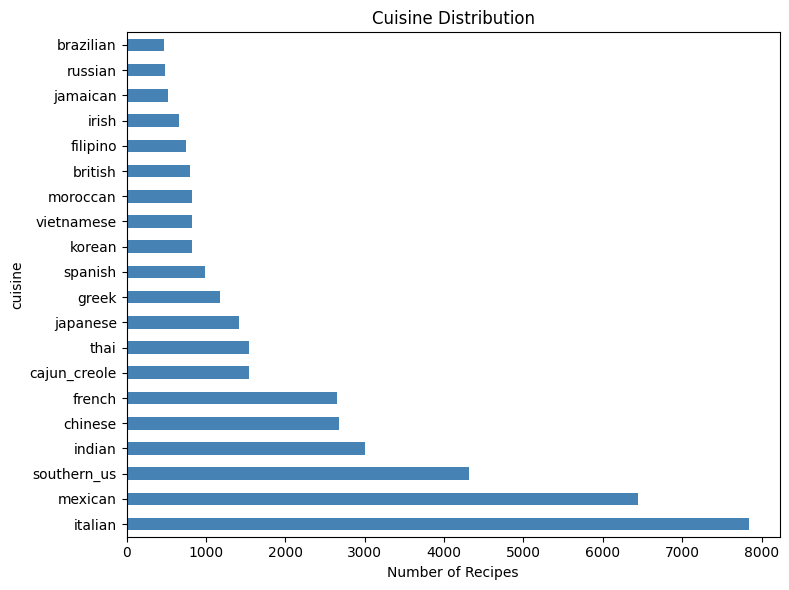

In [ ]:
cuisine_counts = train_df['cuisine'].value_counts()
cuisine_counts.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.xlabel('Number of Recipes')
plt.title('Cuisine Distribution')
plt.tight_layout()
plt.show()

### Top 15 ingredients

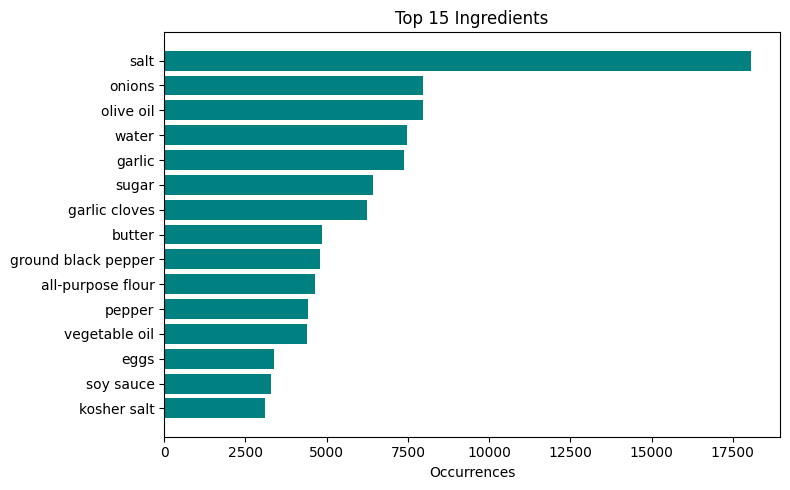

In [ ]:
all_ingredients = [ing for row in train_df['ingredients'] for ing in row]
top15 = Counter(all_ingredients).most_common(15)
labels, values = zip(*top15)

plt.figure(figsize=(8, 5))
plt.barh(labels[::-1], values[::-1], color='teal')
plt.xlabel('Occurrences')
plt.title('Top 15 Ingredients')
plt.tight_layout()
plt.show()

### Ingredients per recipe

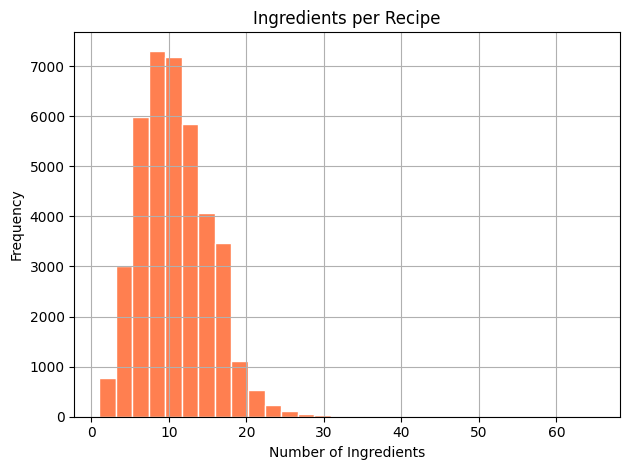

count    39774.00
mean        10.77
std          4.43
min          1.00
25%          8.00
50%         10.00
75%         13.00
max         65.00
Name: n_ingredients, dtype: float64


In [ ]:
train_df['n_ingredients'] = train_df['ingredients'].apply(len)
train_df['n_ingredients'].hist(bins=30, color='coral', edgecolor='white')
plt.xlabel('Number of Ingredients')
plt.ylabel('Frequency')
plt.title('Ingredients per Recipe')
plt.tight_layout()
plt.show()

print(train_df['n_ingredients'].describe().round(2))

## Preprocessing

In [ ]:
# Join ingredient list into a text string
train_df['text'] = train_df['ingredients'].apply(lambda x: ' '.join(x))
test_df['text']  = test_df['ingredients'].apply(lambda x: ' '.join(x))

X = train_df['text']
y = train_df['cuisine']

# TF-IDF vectorization with bigrams
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True)
X_vec = vectorizer.fit_transform(X)

# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(X_vec, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Vocab: {len(vectorizer.vocabulary_):,}')

Train: 31819, Val: 7955, Vocab: 27,340


## Model Training & Optimization

In [21]:
# Tune regularization strength C
for C in [1, 5, 10]:
    model = LogisticRegression(C=C, max_iter=300, solver='saga', random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    print(f'C={C:3d}  ->  Accuracy: {acc:.4f}')

C=  1  ->  Accuracy: 0.7716
C=  5  ->  Accuracy: 0.7827
C= 10  ->  Accuracy: 0.7793


In [22]:
# Final model with best C=10
final_model = LogisticRegression(C=10, max_iter=300, solver='saga', random_state=42)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_val)

print(f'Accuracy: {accuracy_score(y_val, y_pred):.4f}')

Accuracy: 0.7793


## Evaluation

In [23]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

   brazilian       0.77      0.61      0.68        93
     british       0.55      0.44      0.49       161
cajun_creole       0.77      0.69      0.73       309
     chinese       0.79      0.85      0.82       535
    filipino       0.74      0.52      0.61       151
      french       0.57      0.63      0.60       529
       greek       0.77      0.66      0.71       235
      indian       0.87      0.91      0.89       601
       irish       0.65      0.45      0.53       133
     italian       0.81      0.87      0.84      1568
    jamaican       0.87      0.74      0.80       105
    japanese       0.76      0.72      0.74       284
      korean       0.84      0.73      0.78       166
     mexican       0.88      0.92      0.90      1288
    moroccan       0.83      0.73      0.77       164
     russian       0.65      0.37      0.47        98
 southern_us       0.72      0.80      0.75       864
     spanish       0.65    

## Predict Test Set

In [24]:
# Train on full dataset, predict test set
final_model.fit(X_vec, y)
X_test_vec = vectorizer.transform(test_df['text'])

submission = pd.DataFrame({'id': test_df['id'], 'cuisine': final_model.predict(X_test_vec)})
submission.to_csv('submission.csv', index=False)
print('Saved: submission.csv')
submission.head()

Saved: submission.csv


,id,cuisine
0,18009,irish
1,28583,southern_us
2,41580,italian
3,29752,cajun_creole
4,35687,italian


## Export Model for Website
Generates  — copy it next to  and .

In [ ]:
## Export Model Snippet for Website
# Run this after training. It writes model.js — paste its contents into your website.

import json
import numpy as np

TOP_N = 100  # top discriminative tokens per cuisine to keep

idx_to_token = {v: k for k, v in vectorizer.vocabulary_.items()}
coef = final_model.coef_          # shape (20, vocab_size)
classes = list(final_model.classes_)

# Keep union of top N tokens per class
keep_indices = set()
for row in coef:
    top = np.argsort(row)[-TOP_N:]
    keep_indices.update(top.tolist())

keep_indices = sorted(keep_indices)
idx_remap = {old: new for new, old in enumerate(keep_indices)}

slim_vocab = {idx_to_token[i]: idx_remap[i] for i in keep_indices}
slim_coef  = coef[:, keep_indices].tolist()
intercept  = final_model.intercept_.tolist()

snippet = """// AUTO-GENERATED by whats_cooking.ipynb — do not edit manually.
// Paste this file content into model.js alongside index.html and style.css
const MODEL = {{
  classes: {classes},
  vocab:   {vocab},
  coef:    {coef},
  intercept: {intercept}
}};""".format(
    classes=json.dumps(classes),
    vocab=json.dumps(slim_vocab, separators=(",", ":")),
    coef=json.dumps(slim_coef, separators=(",", ":")),
    intercept=json.dumps(intercept, separators=(",", ":"))
)

with open("model.js", "w") as f:
    f.write(snippet)

print(f"Tokens in slim vocab: {len(slim_vocab):,}")
print(f"Saved: model.js  ({len(snippet)//1024} KB)")
print("
Done — copy model.js next to index.html and style.css")
